In [4]:
import torch

In [ ]:
x= torch.arange(12)
x

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [ ]:
x=x.reshape(3,1,4)
x

tensor([[[ 0,  1,  2,  3]],

        [[ 4,  5,  6,  7]],

        [[ 8,  9, 10, 11]]])

Backoropagation

In [ ]:
x= torch.arange(0,1,step=0.1, requires_grad=True)
x

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000], requires_grad=True)

In [ ]:
y=3* x**2 +2 *x
y

tensor([0.0000, 0.2300, 0.5200, 0.8700, 1.2800, 1.7500, 2.2800, 2.8700, 3.5200,
        4.2300], grad_fn=<AddBackward0>)

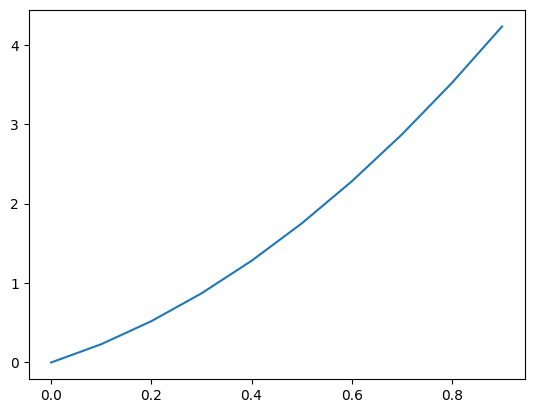

In [ ]:
import matplotlib.pyplot as plt
plt.plot(x.detach().numpy(),y.detach().numpy())

In [ ]:
y.backward(gradient=torch.ones(10))

In [ ]:
assert torch.all(6*x+2==x.grad)

In [ ]:
x.grad

tensor([2.0000, 2.6000, 3.2000, 3.8000, 4.4000, 5.0000, 5.6000, 6.2000, 6.8000,
        7.4000])

In [ ]:
x

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000], requires_grad=True)

In [ ]:
x.device

device(type='cpu')

In [ ]:
x.to('cuda')

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000], device='cuda:0', grad_fn=<ToCopyBackward0>)

In [ ]:
x.to('cuda') + torch.arange(10, device='cuda')

tensor([0.0000, 1.1000, 2.2000, 3.3000, 4.4000, 5.5000, 6.6000, 7.7000, 8.8000,
        9.9000], device='cuda:0', grad_fn=<AddBackward0>)

In [ ]:
torch.set_default_device('cuda')

Linear Regression


In [52]:
import matplotlib.pyplot as plt

n_point = 1000

#generate x value distribution
x=torch.randn(n_point,1, device='cuda')

y= -5 * x + 2 + torch.randn(n_point,1, device='cuda')


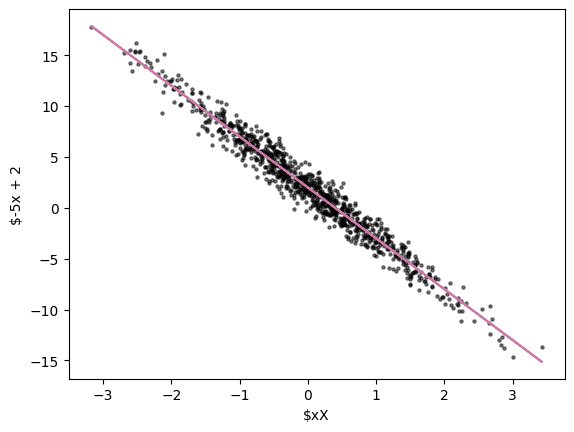

In [53]:
#example of a known y. the purpose of regression is to find y, which is a ground truth.

plt.xlabel('$xX')
plt.ylabel('$-5x + 2')

plt.scatter(x.cpu(), y.cpu(), s=5, c='black', alpha=0.5)
plt.plot(x.cpu(), (-5*x + 2).cpu(), c='#CC79A7')


In [54]:
device = 'cuda'

w = torch.normal ( mean=0, std=0.01, size=(1,), requires_grad= True, device=device)
b = torch.zeros ((1,), requires_grad=True, device=device)


In [55]:


#hypothesis functions
h=lambda x: w * x + b

#loss function
se=lambda y_hat, y:(y_hat-y) ** 2

In [65]:

import numpy as np
n_iter = 30
lr=0.01
batch_size = 4

for _ in range (n_iter):
  indexes = np.random.permutation(len(x))[:batch_size]
  loss = se(h(x[indexes]), y[indexes]).mean()
  loss.backward()
  with torch.no_grad():
    w -= w.grad * lr
    b -= b.grad * lr
    w.grad.zero_()
    b.grad.zero_()

In [66]:
w[0]


tensor(-4.9419, device='cuda:0', grad_fn=<SelectBackward0>)

In [67]:
b[0]

tensor(2.0295, device='cuda:0', grad_fn=<SelectBackward0>)